In [1]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Setup

In [2]:
import numpy as np
import os
import torch
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import build_optimizer, fit_2D, fit_2d_per_slice
from utils.loss_functions import binary_2d_loss, ssim_L1_2d_loss
from models.alzheimers_cure_2d import VAE
from models.no_more_alzheimer_2d import UNet2D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


## One model for whole brain

### Load, Run and Save VAE

In [5]:
vae = VAE(latent_dim=64).to(device)
vae_optimizer = build_optimizer(vae, lr=1e-4, wd=1e-4)

# We take the saved model
if(os.path.exists("out/vae_models/2d_vae_model.pt")):
    vae.load_state_dict(torch.load("out/vae_models/2d_vae_model.pt"))


In [6]:
vae, vae_loss, vae_snapshots = fit_2D(vae, 
                            device,
                            data_loader,
                            training_pairs, 
                            ssim_L1_2d_loss, 
                            optimizer=vae_optimizer, 
                            epochs=501, 
                            save_every=250,
                            )

Saved snapshot for pair 0 at slice idx 93
Saved snapshot for pair 250 at slice idx 93
Saved snapshot for pair 500 at slice idx 93


In [7]:
output_dir = "out/vae_models"
os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, "2d_vae_model.pt")
torch.save(vae.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to out/vae_models/2d_vae_model.pt


### Load, Run and Save UNET

In [20]:
unet = UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)
unet_optimizer = build_optimizer(unet, lr=1e-4, wd=1e-4)

In [8]:
unet, unet_loss, unet_snapshots = fit_2D(unet, 
                            device,
                            data_loader,
                            training_pairs, 
                            ssim_L1_2d_loss, 
                            optimizer=unet_optimizer, 
                            epochs=501, 
                            save_every=250,
                            )

Saved snapshot for pair 0 at slice idx 93
Saved snapshot for pair 250 at slice idx 93
Saved snapshot for pair 500 at slice idx 93


In [21]:
output_dir = "out/unet_models"
os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, "2d_unet_model.pt")
torch.save(unet.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to out/unet_models/2d_unet_model.pt


### Display Results

Displaying comparison for iteration 0 (U-Net) vs 0 (VAE)


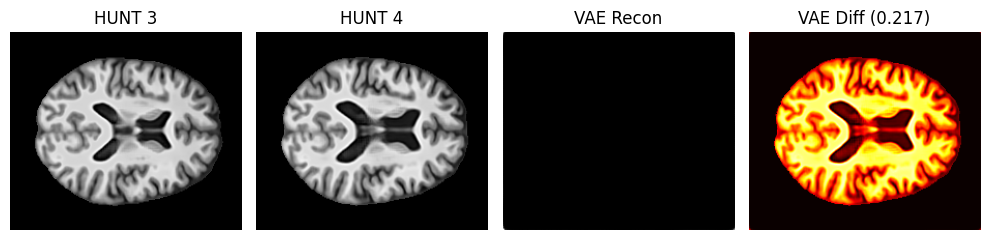

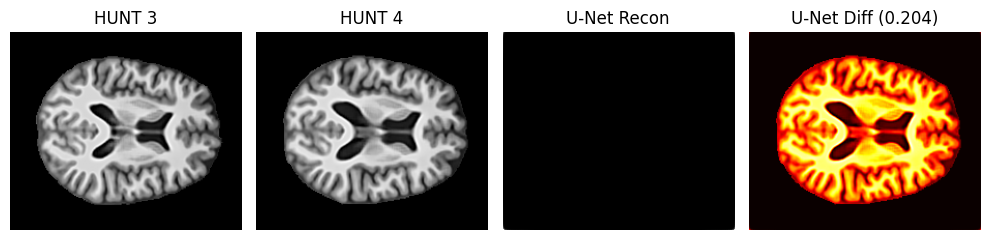

Displaying comparison for iteration 250 (U-Net) vs 250 (VAE)


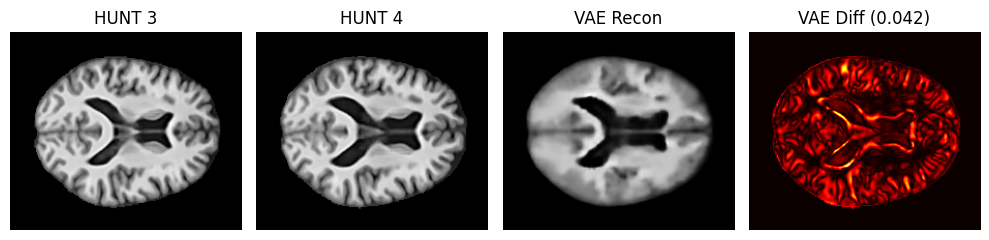

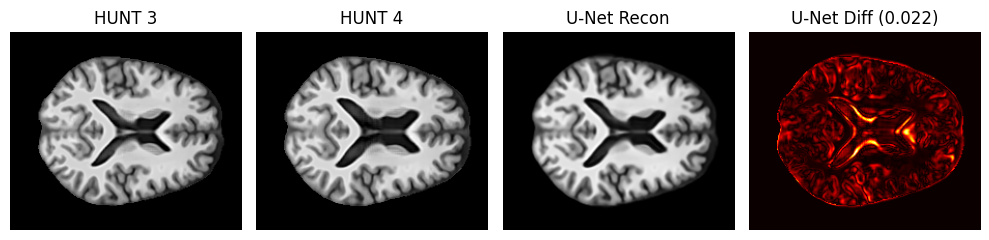

Displaying comparison for iteration 500 (U-Net) vs 500 (VAE)


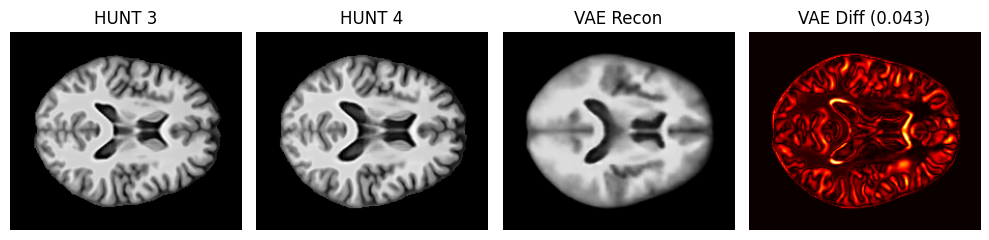

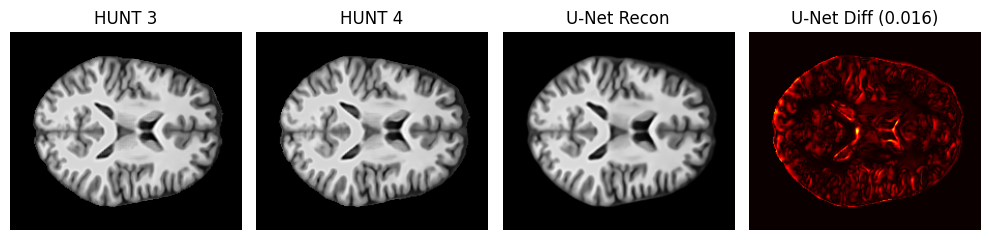

In [9]:
# Make sure both have the same number of snapshots
for unet_snap, vae_snap in zip(unet_snapshots, vae_snapshots):
    print(f"Displaying comparison for iteration {unet_snap['iter']} (U-Net) vs {vae_snap['iter']} (VAE)")

    # Compute absolute difference maps
    diff_unet = np.abs(unet_snap["recon"] - unet_snap["y"])
    diff_vae = np.abs(vae_snap["recon"] - vae_snap["y"])

    vae_slices = [vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae]
    unet_slices = [unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet]

    slices = [
        unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet,
        vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae
    ]

    unet_labels = ["HUNT 3", "HUNT 4", "U-Net Recon", f"U-Net Diff ({np.mean(diff_unet):.3f})"]
    vae_labels = ["HUNT 3", "HUNT 4", "VAE Recon", f"VAE Diff ({np.mean(diff_vae):.3f})"]
    
    colors = ["gray", "gray", "gray", "hot"]

    # Display slices on top of each other
    data_loader.display_slices(vae_slices, slice_labels=vae_labels, slice_colors=colors)
    data_loader.display_slices(unet_slices, slice_labels=unet_labels, slice_colors=colors)


## One model per Slice Index

In [10]:
# Load VAE and optimizer
slice_vae_models = [VAE(latent_dim=64).to(device)] * 193
slice_vae_optimizers = [build_optimizer(vae, lr=1e-4, wd=1e-4) for vae in slice_vae_models]

# Load UNET and optimizer
slice_unet_models = [UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)] * 193
slice_unet_optimizers = [build_optimizer(unet, lr=1e-4, wd=1e-4) for unet in slice_unet_models]

In [11]:
slice_vae_models, slice_vae_loss, slice_vae_snapshots = fit_2d_per_slice(
    slice_vae_models,
    device,
    data_loader,
    training_pairs,
    ssim_L1_2d_loss,
    optimizers=slice_vae_optimizers,
    epochs=501,
    save_every=250,
)

Saved snapshot at epoch 0
Saved snapshot at epoch 250
Saved snapshot at epoch 500


In [12]:
slice_unet_models, slice_unet_loss, slice_unet_snapshots = fit_2d_per_slice(
    slice_unet_models,
    device,
    data_loader,
    training_pairs,
    ssim_L1_2d_loss,
    optimizers=slice_unet_optimizers,
    epochs=501,
    save_every=250,
)

Saved snapshot at epoch 0
Saved snapshot at epoch 250
Saved snapshot at epoch 500


Epoch 0: U-Net slice=? | VAE slice=?


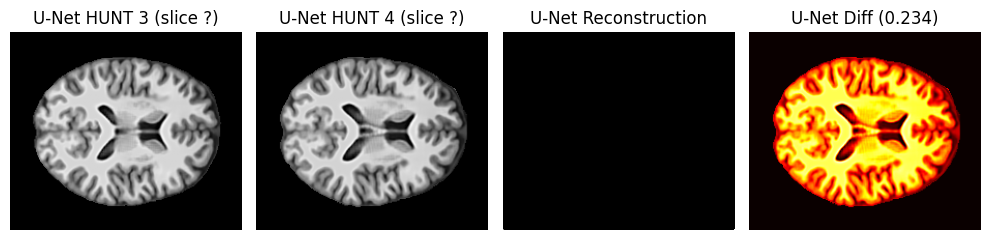

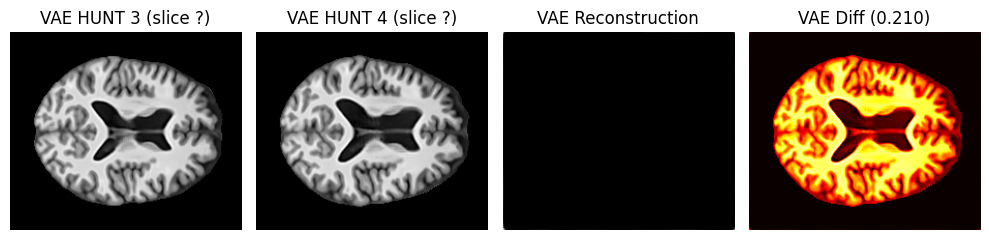

Epoch 250: U-Net slice=? | VAE slice=?


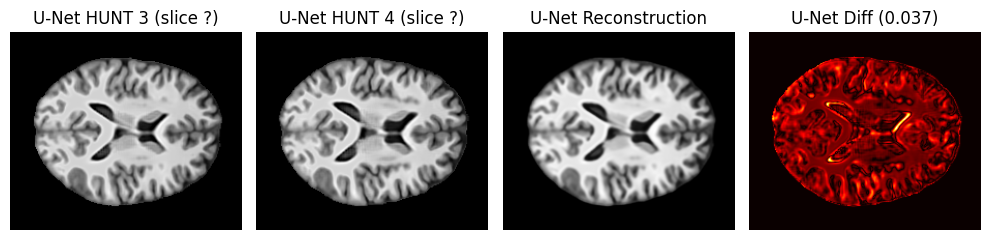

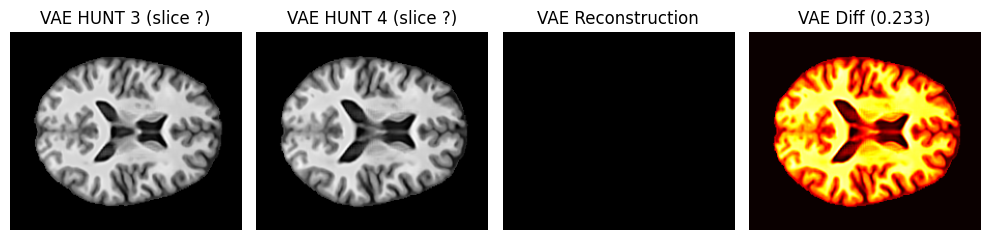

Epoch 500: U-Net slice=? | VAE slice=?


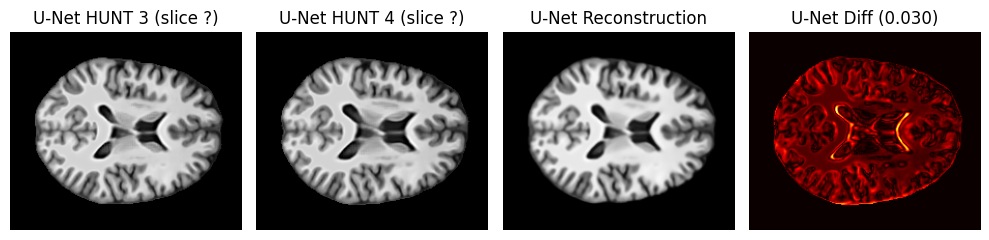

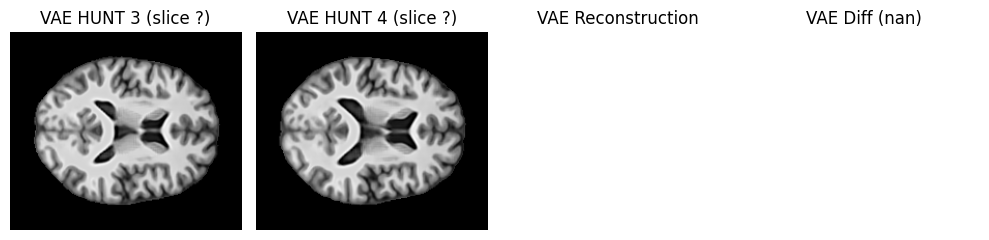

In [13]:
import random
import numpy as np
from collections import defaultdict

def _group_by_epoch(snaps):
    by_epoch = defaultdict(list)  # epoch -> [snapshots]
    for s in snaps:
        ep = s.get("iter", None)
        if ep is not None:
            by_epoch[ep].append(s)
    return by_epoch

u_by_epoch = _group_by_epoch(slice_unet_snapshots)
v_by_epoch = _group_by_epoch(slice_vae_snapshots)

# Only show epochs present in BOTH sets
common_epochs = sorted(set(u_by_epoch.keys()) & set(v_by_epoch.keys()))
if not common_epochs:
    raise RuntimeError("No overlapping epochs between U-Net and VAE snapshots.")

for ep in common_epochs:
    # Pick a random snapshot (slice/model) from this epoch for each type
    unet_snap = random.choice(u_by_epoch[ep])
    vae_snap  = random.choice(v_by_epoch[ep])

    print(f"Epoch {ep}: U-Net slice={unet_snap.get('slice_idx','?')} | VAE slice={vae_snap.get('slice_idx','?')}")

    # Differences
    diff_unet = np.abs(unet_snap["recon"] - unet_snap["y"])
    diff_vae  = np.abs(vae_snap["recon"]  - vae_snap["y"])

    # Prepare rows: U-Net (top), VAE (bottom)
    colors = ["gray", "gray", "gray", "hot"]

    unet_slices = [unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet]
    unet_labels = [
        f"U-Net HUNT 3 (slice {unet_snap.get('slice_idx','?')})",
        f"U-Net HUNT 4 (slice {unet_snap.get('slice_idx','?')})",
        "U-Net Reconstruction",
        f"U-Net Diff ({np.mean(diff_unet):.3f})",
    ]

    vae_slices = [vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae]
    vae_labels = [
        f"VAE HUNT 3 (slice {vae_snap.get('slice_idx','?')})",
        f"VAE HUNT 4 (slice {vae_snap.get('slice_idx','?')})",
        "VAE Reconstruction",
        f"VAE Diff ({np.mean(diff_vae):.3f})",
    ]

    # Stack vertically (two calls = two rows)
    data_loader.display_slices(unet_slices, slice_labels=unet_labels, slice_colors=colors)
    data_loader.display_slices(vae_slices,  slice_labels=vae_labels,  slice_colors=colors)


## Compare Universal and Slicewise Models

From Earlier we have the models
|                           | **VAE**                                          | **UNet**                                           |
| ------------------------- | ------------------------------------------------------ | -------------------------------------------------------- |
| **Whole dataset**         | `vae`               | `unet`               |
| **Slice-specific models** | `slice_vae_models`  | `slice_unet_models`  |


### See Loss statistics

In [14]:
print(vae_loss)

[{'slice': 93, 'loss': 0.6070602536201477}, {'slice': 93, 'loss': 0.5398366451263428}, {'slice': 93, 'loss': 0.4657945930957794}, {'slice': 93, 'loss': 0.47840645909309387}, {'slice': 93, 'loss': 0.48004716634750366}, {'slice': 93, 'loss': 0.558152437210083}, {'slice': 93, 'loss': 0.46132856607437134}, {'slice': 93, 'loss': 0.464705228805542}, {'slice': 93, 'loss': 0.492823988199234}, {'slice': 93, 'loss': 0.5120454430580139}, {'slice': 93, 'loss': 0.45767974853515625}, {'slice': 93, 'loss': 0.4575217366218567}, {'slice': 93, 'loss': 0.4554842412471771}, {'slice': 93, 'loss': 0.4983999729156494}, {'slice': 93, 'loss': 0.41450151801109314}, {'slice': 93, 'loss': 0.48594579100608826}, {'slice': 93, 'loss': 0.46674516797065735}, {'slice': 93, 'loss': 0.44855114817619324}, {'slice': 93, 'loss': 0.4654737412929535}, {'slice': 93, 'loss': 0.4414559602737427}, {'slice': 93, 'loss': 0.476936936378479}, {'slice': 93, 'loss': 0.45427268743515015}, {'slice': 93, 'loss': 0.4840724468231201}, {'sli

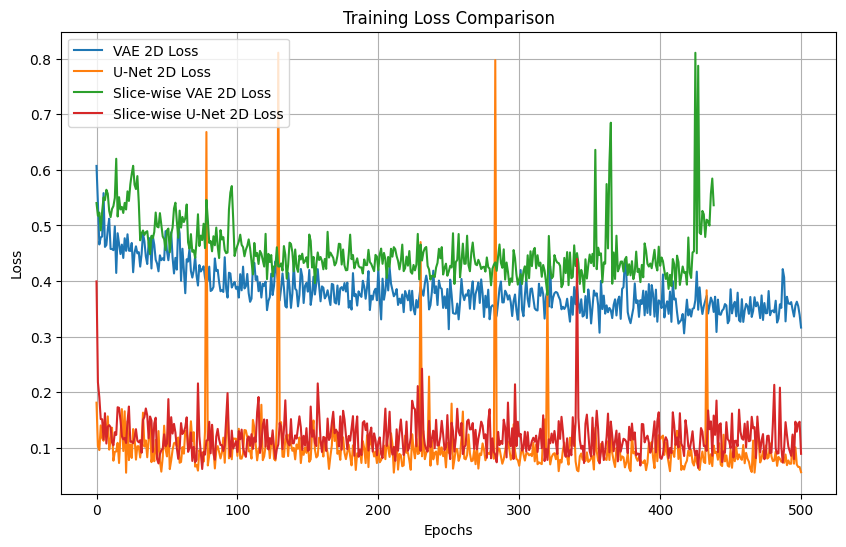

In [15]:
import matplotlib.pyplot as plt
# Compare the four loss histories
# We have vae_loss, unet_loss, slice_vae_loss, slice_unet_loss
plt.figure(figsize=(10,6))
plt.plot([item['loss'] for item in vae_loss], label="VAE 2D Loss")
plt.plot([item['loss'] for item in unet_loss], label="U-Net 2D Loss")
plt.plot([item['loss'] for item in slice_vae_loss], label="Slice-wise VAE 2D Loss")
plt.plot([item['loss'] for item in slice_unet_loss], label="Slice-wise U-Net 2D Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.show()

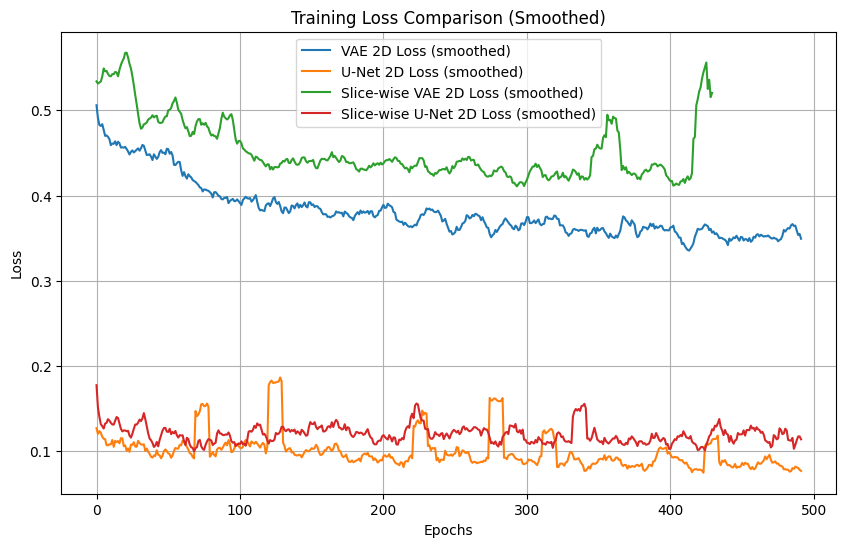

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def smooth(y, window=10):
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window)/window, mode='valid')

vae_y = [item['loss'] for item in vae_loss]
unet_y = [item['loss'] for item in unet_loss]
slice_vae_y = [item['loss'] for item in slice_vae_loss]
slice_unet_y = [item['loss'] for item in slice_unet_loss]

plt.figure(figsize=(10,6))
plt.plot(smooth(vae_y), label="VAE 2D Loss (smoothed)")
plt.plot(smooth(unet_y), label="U-Net 2D Loss (smoothed)")
plt.plot(smooth(slice_vae_y), label="Slice-wise VAE 2D Loss (smoothed)")
plt.plot(smooth(slice_unet_y), label="Slice-wise U-Net 2D Loss (smoothed)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Smoothed)")
plt.legend()
plt.grid()
plt.show()


### Import and Generate Slices

In [17]:
slice = 93

x_num, y_num = data_loader.get_slice(training_pairs[0][0], slice), data_loader.get_slice(training_pairs[0][1], slice)  # We load image from path
x = data_loader.to_torch_img(x_num, device)             # We convert image to a torch tensor

vae_recon, _, _ = vae(x)
unet_recon, _, _ = unet(x)

slice_vae_recon, _, _ = slice_vae_models[slice](x)
slice_unet_recon, _, _ = slice_unet_models[slice](x)

In [18]:
# Convert Tensor reconstructions to numpy for display
vae_recon = data_loader.to_numpy_img(vae_recon)
unet_recon = data_loader.to_numpy_img(unet_recon)
slice_vae_recon = data_loader.to_numpy_img(slice_vae_recon)
slice_unet_recon = data_loader.to_numpy_img(slice_unet_recon)

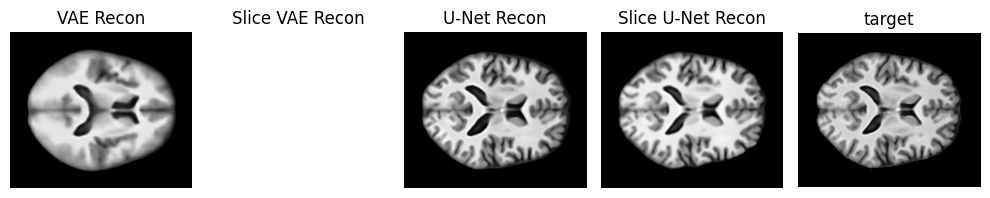

In [19]:
data_loader.display_slices(
    slices=[vae_recon, slice_vae_recon, unet_recon, slice_unet_recon, y_num],
    slice_labels=["VAE Recon", "Slice VAE Recon", "U-Net Recon", "Slice U-Net Recon", "target"],
    slice_colors=["gray", "gray", "gray", "gray", "gray"]
)